# Libraries used


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/data.csv")
df.head()
# print(df)

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,1734616,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,1419098,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,1797916,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,1805337,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,1351334,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1963 entries, 0 to 1962
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1963 non-null   int64 
 1   Age                  1963 non-null   int64 
 2   Gender               1963 non-null   object
 3   Hormonal Changes     1963 non-null   object
 4   Family History       1963 non-null   object
 5   Race/Ethnicity       1963 non-null   object
 6   Body Weight          1963 non-null   object
 7   Calcium Intake       1963 non-null   object
 8   Vitamin D Intake     1963 non-null   object
 9   Physical Activity    1963 non-null   object
 10  Smoking              1962 non-null   object
 11  Alcohol Consumption  975 non-null    object
 12  Medical Conditions   1316 non-null   object
 13  Medications          978 non-null    object
 14  Prior Fractures      1963 non-null   object
 15  Osteoporosis         1963 non-null   int64 
dtypes: int

Id                       0
Age                      0
Gender                   0
Hormonal Changes         0
Family History           0
Race/Ethnicity           0
Body Weight              0
Calcium Intake           0
Vitamin D Intake         0
Physical Activity        0
Smoking                  1
Alcohol Consumption    988
Medical Conditions     647
Medications            985
Prior Fractures          0
Osteoporosis             0
dtype: int64

In [4]:
# Handling missing values for Categorical Columns
cols_to_fix = ['Alcohol Consumption', 'Medical Conditions', 'Medications']
for col in cols_to_fix:
    if col in df.columns:
        df[col] = df[col].fillna('No')
print('Missing values handled.')

Missing values handled.


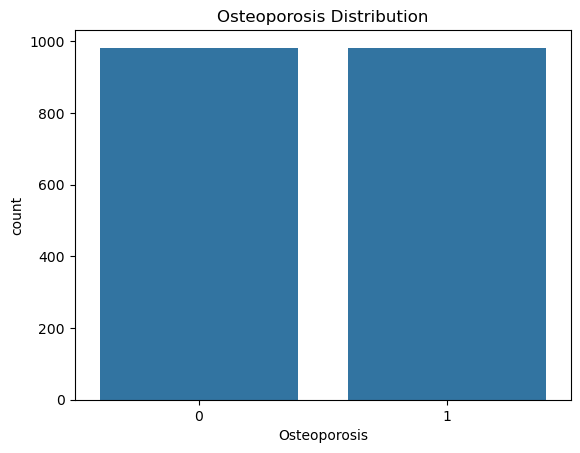

In [5]:
sns.countplot(x="Osteoporosis", data=df)
plt.title("Osteoporosis Distribution")
plt.show()

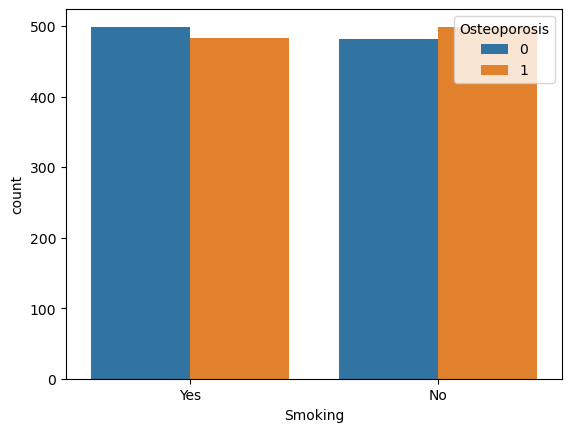

In [6]:
sns.countplot(x="Smoking", hue="Osteoporosis", data=df)
plt.show()

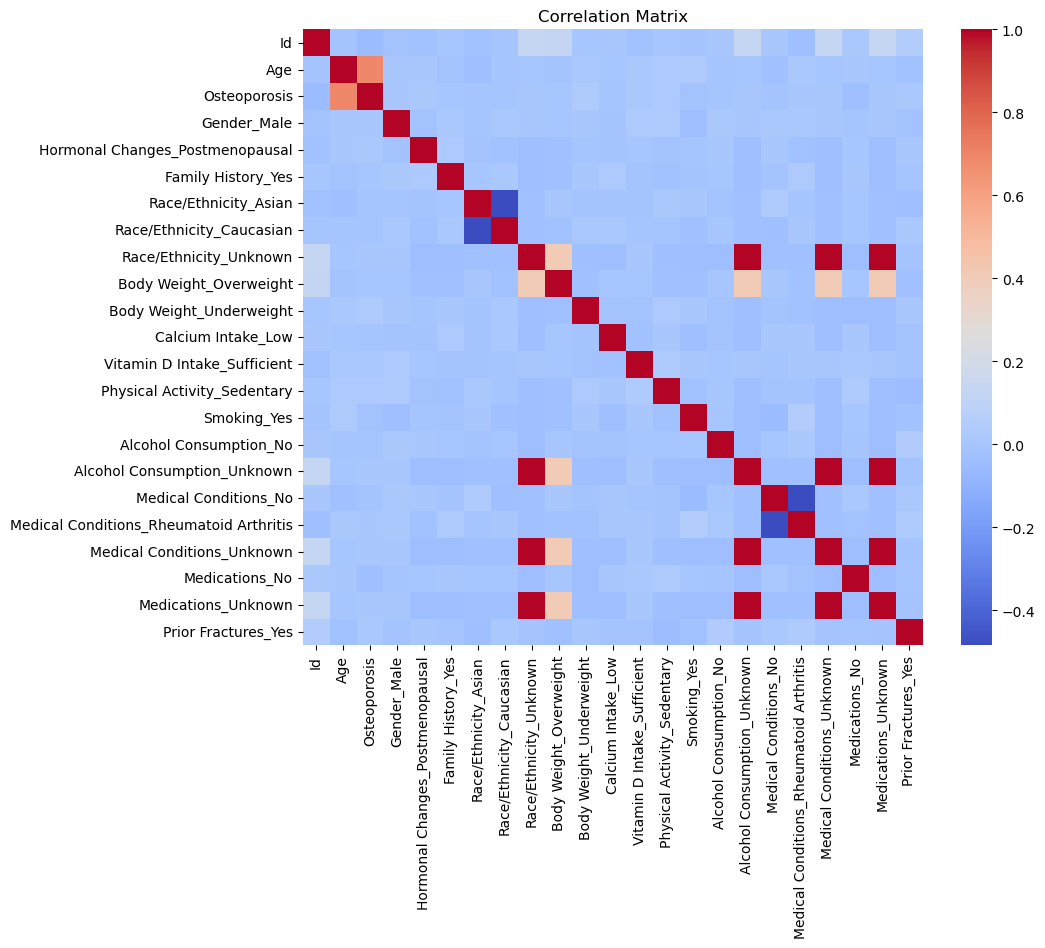

In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded.drop("Osteoporosis", axis=1))

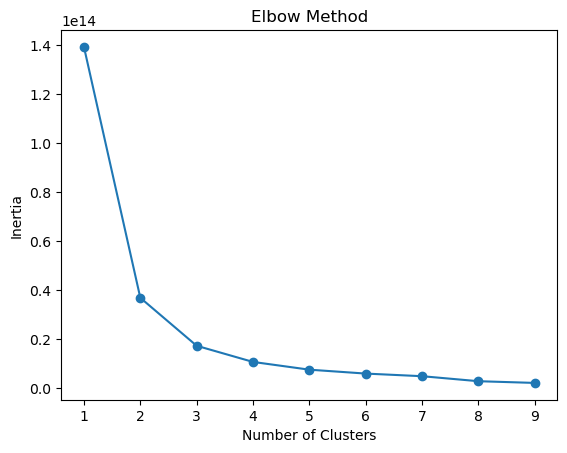

In [9]:
from sklearn.cluster import KMeans

X = df_encoded.drop("Osteoporosis", axis=1)

inertia = []

for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

### encoder lines


In [ ]:
# # Import metrics
# from sklearn.metrics import (
#     accuracy_score,
#     confusion_matrix,
#     classification_report,
#     precision_score,
#     recall_score,
#     f1_score
# )

# # Predict
# y_pred = model.predict(X_test)

# # 🔹 Accuracy
# accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy:", accuracy)

# # 🔹 Precision
# precision = precision_score(y_test, y_pred, average='weighted')
# print("Precision:", precision)

# # 🔹 Recall
# recall = recall_score(y_test, y_pred, average='weighted')
# print("Recall:", recall)

# # 🔹 F1 Score
# f1 = f1_score(y_test, y_pred, average='weighted')
# print("F1 Score:", f1)

# # 🔹 Confusion Matrix (Error Breakdown)
# cm = confusion_matrix(y_test, y_pred)
# print("\nConfusion Matrix:\n", cm)

# # 🔹 Detailed Report
# report = classification_report(y_test, y_pred)
# print("\nClassification Report:\n", report)

NameError: name 'model' is not defined